# E-Commerce Sales & Customer Analytics
A portfolio-ready analysis of sales, profitability, regional performance and customer segmentation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/ecommerce_sales.csv', parse_dates=['Order_Date'])
df.head()


,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Payment_Method,Shipping_Type,Quantity,Unit_Price,Discount,Sales,Profit,Rating,Order_Status
0,ORD102315,2024-01-01,CUST1035,Makeup Set,Beauty,Central,Net Banking,Standard,1,1600.73,0.00,1600.73,291.53,4.7,Delivered
1,ORD102441,2024-01-01,CUST1282,Backpack,Fashion,Central,Credit Card,Standard,1,6304.62,0.00,6304.62,1942.41,4.5,Delivered
2,ORD102258,2024-01-01,CUST1323,Wireless Headphones,Electronics,South,UPI,Express,3,38892.74,0.15,99176.49,16363.28,4.7,Delivered
3,ORD101481,2024-01-01,CUST1576,Bluetooth Speaker,Electronics,North,Net Banking,Standard,1,32354.49,0.10,29119.04,2010.08,4.3,Delivered
4,ORD101487,2024-01-01,CUST1554,Laptop Stand,Electronics,North,Net Banking,Standard,2,19677.94,0.20,31484.70,-627.08,4.5,Delivered


In [2]:
print('Shape:', df.shape)
print('Missing values:')
display(df.isna().sum())
print('Duplicate rows:', df.duplicated().sum())


Shape: (3500, 15)
Missing values:


Order_ID          0
Order_Date        0
Customer_ID       0
Product           0
Category          0
Region            0
Payment_Method    0
Shipping_Type     0
Quantity          0
Unit_Price        0
Discount          0
Sales             0
Profit            0
Rating            0
Order_Status      0
dtype: int64

Duplicate rows: 0


In [3]:
kpis = {
    'Total Sales': df['Sales'].sum(),
    'Total Profit': df['Profit'].sum(),
    'Orders': df['Order_ID'].nunique(),
    'Customers': df['Customer_ID'].nunique(),
    'Average Order Value': df['Sales'].mean()
}
pd.Series(kpis)


Total Sales            6.573184e+07
Total Profit           1.539183e+07
Orders                 3.500000e+03
Customers              5.970000e+02
Average Order Value    1.878053e+04
dtype: float64

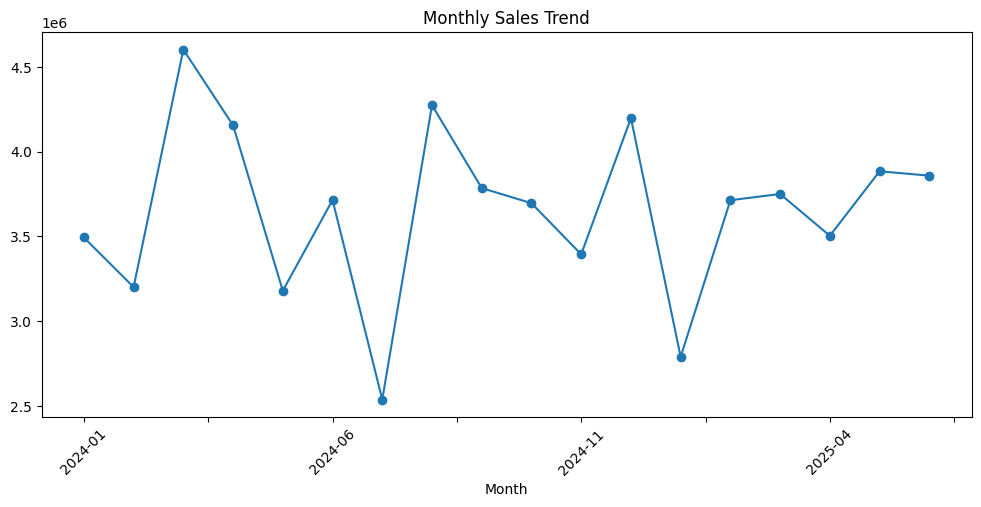

In [4]:
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly = df.groupby('Month')['Sales'].sum()
monthly.plot(figsize=(12,5), marker='o', title='Monthly Sales Trend')
plt.xticks(rotation=45)
plt.show()


In [5]:
df.groupby('Category')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)


,Sales,Profit
Category,,
Electronics,39796624.06,9462777.45
Home & Kitchen,12065365.70,2662933.30
Fashion,6076708.46,1429541.81
Sports,4883554.83,1156923.24
Beauty,2909585.62,679653.13


In [6]:
snapshot = df['Order_Date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer_ID').agg(
    Recency=('Order_Date', lambda x: (snapshot-x.max()).days),
    Frequency=('Order_ID','nunique'),
    Monetary=('Sales','sum')
).reset_index()
rfm.head()


,Customer_ID,Recency,Frequency,Monetary
0,CUST1001,5,6,102089.15
1,CUST1002,7,5,70748.57
2,CUST1003,14,9,277959.34
3,CUST1004,9,3,228227.88
4,CUST1005,11,6,221640.27


## Business Recommendations
Focus retention efforts on at-risk customers, prioritize high-revenue categories/products, and monitor regional and monthly trends for inventory and marketing decisions.